# Synchronization Classification of Signals of Individual Faces

In [ ]:
#| default_exp dg_synch_class

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

In [ ]:
#| hide
#| eval: false

from fhemb.piece import Piece
from fhemb.utils.factories import wfactory, pca_factory

DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.paths
DEBUG:fhemb.config.settings:Loading environment from /Users/radned/.config/fhemb/.env.db
DEBUG:fhemb.config.settings:Running locally


## Define Segments of the Opera 

In [ ]:
#| eval: false

fftrio_segment0 = (14200, 14450)
fftrio_segment1 = (14950, 15200)

In [ ]:
#| eval: false

fftrio0 = Piece(
    time_interval=fftrio_segment0,
    title="Don Giovanni", 
    subjs=(40,76)
)

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=(40, 76), args=() and kwargs={'time_interval': (14200, 14450), 'title': 'Don Giovanni'}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76] and args=() and kwargs={'time_interval': (14200, 14450), 'title': 'Don Giovanni'}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 76)]


In [ ]:
#| eval: false

fftrio1 = Piece(
    time_interval=fftrio_segment1,
    title="Don Giovanni", 
    subjs=(40,76)
)

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=(40, 76), args=() and kwargs={'time_interval': (14950, 15200), 'title': 'Don Giovanni'}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76] and args=() and kwargs={'time_interval': (14950, 15200), 'title': 'Don Giovanni'}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 76)]


In [ ]:
#| eval: false
FFTRIO01_DIRNAME = 'fftrio0_fftrio1/'

In [ ]:
#| eval: false
dirname = FFTRIO01_DIRNAME + 'face_db4_fast_minmax(2,3)'

## Define Embeddings
> 80th percentile in the frequency band 0.1 - 0.39 Hz of the Daubechies wavelet `db4`

In [ ]:
#| eval: false

emb0 = fftrio0.face_t.project(  
    fbands=[2,3],
    features=['p80'],
    wdfactory=wfactory('db4',8)
)

emb1 = fftrio1.face_t.project(  
    fbands=[2,3],
    features=['p80'],
    wdfactory=wfactory('db4',8)
)

 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj43, subj44, subj45, subj46, subj47, subj48, subj49, subj50, subj51, subj52, subj53, subj54, subj55, subj56, subj57, subj58, subj59, subj60, subj61, subj62, subj63, subj64, subj65, subj66, subj67, subj68, subj69, subj70, subj71, subj72, subj73, subj74, subj75, subj76 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 14450 ORDER BY frame_number
 [DEBUG] piece.start: SSH disabled; using direct DB connection
 [DEBUG] dbms.__enter__: Database connection opened: True (conn.closed=0)
 [DEBUG] dbms.__enter__: Database cursor opened: True
 [INFO] dbms.data_query: Fetching time series of ['subj40', 'subj41', 'subj42', 'subj43', 'subj44', 'subj45', 'subj46', 'subj47', 'subj48', 'subj49', 'subj50', 'subj51', 'subj52', 'subj53', 'subj54', 'subj55', 'subj56', 'subj57', 'subj58', 'subj59', 'subj60', 'subj61', 'subj62', 'subj63', 'sub

In [ ]:
#| eval: false

emb0.frequencies

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'frequencies' across embeddings: found in ['percentiles_ts']


[(0.1, 0.39)]

In [ ]:
#| eval: false
from fhemb.utils.cutils import prepare_data, calc_and_save_pr_accuracy, plot_accuracy_summary

## Synchronization Classification of Pairwise Relation (Secondary) Embeddings

In [ ]:
#| eval: false
                 
for feature in emb0.features:                                        #
                                          # iterate over this list of features of the Embedding object 
    print(f"Feature: {feature}")
    X, y = prepare_data(                  # prepare the matrix X and label vector y for the two groups
        emb0.get_df_ts_subjs(feature).T,  # samples for group 0
        emb1.get_df_ts_subjs(feature).T   # samples for group 1
    )
    print(f"Shape: {X.shape}")            # matrix (n_samples x n_dataframes)
    filename=calc_and_save_pr_accuracy(   # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename  
        X[y==0],                          # group 0
        X[y==1],                          # group 1
        dirname=dirname,                  # directory in which the results Excel file will be stored
        alignment_type='fastdtw',         # alignment method for distance matrix computation
        normalize='minmax',               # normalize after splitting the data into train and test sets
        radius=1,                         # refinement window size in fastdtw (only used for fastdtw)
        feature=feature,                  # feature name for labeling the results
        random_states=10,                 # number of random states for train/test splits in classification
        njobs=8                           # number of jobs for parallelization
    )
    print(f"Saved results to: {filename}")

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [INFO] cutils.calc_and_save_pr_accuracy: 
Accuracy summaries saved to /Users/radned/Projects/ttsembedding/fftrio0_fftrio1/face_db4_fast_minmax(2,3)/acc_summ_p80.xlsx


/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Feature: p80
Shape: (64, 250)


/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 990/990 [00:18<00:00, 53.86it/s]
 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:15<00:00, 56.79it/s]
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/depreca

Saved results to: /Users/radned/Projects/ttsembedding/fftrio0_fftrio1/face_db4_fast_minmax(2,3)/acc_summ_p80.xlsx


In [ ]:
#| eval: false

COLUMNS_FILTER=[                     # list of classifier columns to include in the visualization
        'knn_precomputed', 
        'knn_cosine', 
        'knn_l1', 
        'knn_euclidean', 
        'knn_minkowski', 
        'rotf', 
        'randf', 
        'svm_precomputed', 
        'svm_rbf', 
        'svm_poly', 
        'svm_linear'
    ]

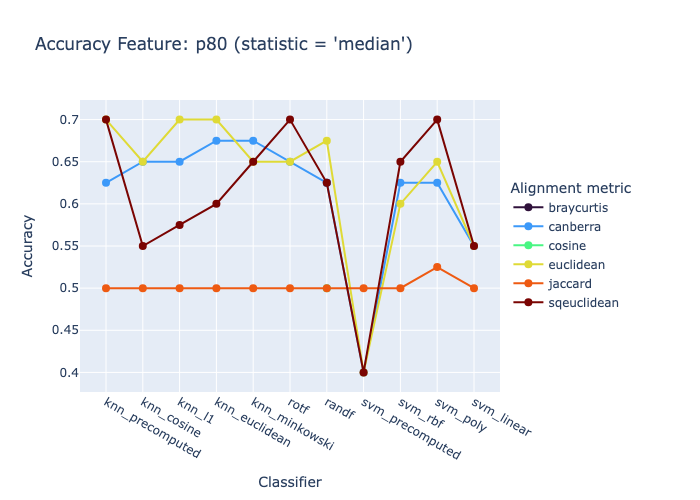

In [ ]:
#| eval: false

plot_accuracy_summary(                  # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` 
    dirname,                            # directory from which the results are loaded
    features=['p80'],                   # the features of the primary embeddings for which the accuracy will be visualized      
    statistics='median',                # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    columns_filter=COLUMNS_FILTER,      # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
);

## Synchronization Classification of Primary Embeddings

In [ ]:
#| eval: false

from dvae.classifier import VAEClassifier

Is cuda available? False
Cuda device count: 0
Using device: cpu
Pyro version: 1.9.1


In [ ]:
#| eval: false

clf = VAEClassifier(
    feature_dim=250,
    z_dim=80,
    hidden_dim=80,
    alpha1=1e-5,
    alpha2=1,
    beta=1e-2,
    corruption=0.0,
    seed=42,
)

In [ ]:
#| eval: false

X_all, y_all = prepare_data(                  # prepare the matrix X and label vector y for the two groups
        emb0.get_df_ts_subjs(feature).T,  # samples for group 0
        emb1.get_df_ts_subjs(feature).T   # samples for group 1
    )

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80


In [ ]:
#| eval: false

from fhemb.utils.cutils import split_scale_data

In [ ]:
#| eval: false

X_train, X_test, y_train, y_test, _ = split_scale_data(
    X_all, 
    y_all,
    test_size=0.3, 
    random_state=0, 
    normalize='meanvar'
)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
#| eval: false

y_pred = clf.fit_predict_on(X_train.squeeze(), y_train.squeeze(), X_test.squeeze(), num_epochs=2000)

 [WARNING] src.utils.logger._propose_threshold: Multiple best accuracies: [0.5        0.5        0.5        0.5        0.5        0.5
 0.90909091 0.90909091 0.90909091 0.95454545 0.95454545 0.95454545
 0.95454545 0.5        0.5        0.5        0.5        0.5       ]


In [ ]:
#| eval: false

from fhemb.utils.cutils import calc_similarity

In [ ]:
#| eval: false

calc_similarity(y_test, y_pred, sim_metric='f1')

0.7493734335839599

In [ ]:
#| eval: false

calc_similarity(y_test, y_pred, sim_metric='accuracy')

0.75

::: {.callout-important title="Classification Accuracy"}
DVAE embeddings remain more linearly and locally separable than secondary (pairwise‑relation) embeddings across both KNN and SVM families. This means the identity manifold is stronger and more coherent than the relation manifold.
In both cases, accuracy is far above the 50 % chance level!
:::